## Competition01 Titanic
### 1. コンペ概要 
Titanic乗客の情報から、生存したかどうかを予測する 

### 2. 目的  
-データ分析の流れを学ぶ  
-前処理を学ぶ  
-初めての機械学習モデルを作成する

### 3. 使用ライブラリ  
-pandas  
-numpy  
-matplotlib  
-scikit-learn

### 4. データ読み込み  

In [466]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [467]:
train = pd.read_csv("../data/train.csv")

### 5. EDA(データ確認)

In [468]:
train.head()

,id,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,3,1,1,female,35.0,1,0,53.1000,S
1,4,0,3,male,35.0,0,0,8.0500,S
2,7,0,3,male,2.0,3,1,21.0750,S
3,9,1,2,female,14.0,1,0,30.0708,C
4,11,1,1,female,58.0,0,0,26.5500,S


-Survived 生還結果←予測対象  
-pclass 客席のクラス(高級1→3安価)  
-sex 性別  
-age 年齢  
-sibsp 乗船していた兄弟、配偶者の数  
-parch 乗船していた両親、子供の数  
-fare 運賃  
-embarked 乗船した港(S=Southampton, C=Cherbourg, Q=Queenstown)

In [469]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        445 non-null    int64  
 1   survived  445 non-null    int64  
 2   pclass    445 non-null    int64  
 3   sex       445 non-null    str    
 4   age       360 non-null    float64
 5   sibsp     445 non-null    int64  
 6   parch     445 non-null    int64  
 7   fare      445 non-null    float64
 8   embarked  443 non-null    str    
dtypes: float64(2), int64(5), str(2)
memory usage: 31.4 KB


In [470]:
train.isnull().sum()

id           0
survived     0
pclass       0
sex          0
age         85
sibsp        0
parch        0
fare         0
embarked     2
dtype: int64

・445人分のデータがある  
・age(年齢)の欠損85(19%)→補完方法を検討する必要あり  
・embarked(乗船した港)の欠損2→最頻値などで保管できそう  
・文字データはembarked(乗船した港)とsex(性別)→機械学習で扱うため数値へ変換する必要あり

In [471]:
train.describe()

,id,survived,pclass,age,sibsp,parch,fare
count,445.000000,445.000000,445.000000,360.000000,445.000000,445.000000,445.000000
mean,456.002247,0.402247,2.296629,29.211583,0.546067,0.431461,33.959971
std,256.703351,0.490903,0.834024,14.154300,1.195247,0.850489,52.079492
min,3.000000,0.000000,1.000000,0.670000,0.000000,0.000000,0.000000
25%,227.000000,0.000000,2.000000,20.000000,0.000000,0.000000,7.925000
50%,463.000000,0.000000,3.000000,28.000000,0.000000,0.000000,15.000000
75%,679.000000,1.000000,3.000000,37.250000,1.000000,1.000000,31.387500
max,888.000000,1.000000,3.000000,80.000000,8.000000,5.000000,512.329200


#### 仮説  
①過半数以上が3ということから、1等客室より3等客室の方が生存率が高そうだと予想できる  
②優先的に避難できていたため女性の方が生存率が高そう  
③優先的に避難できていたため子供の方が生存率が高そう   
④運賃高い方が生存率高そう

#### 仮説の検証

##### ①客室pclass(重要)

In [472]:
train.groupby("pclass")["survived"].mean()

pclass
1    0.685185
2    0.443299
3    0.258333
Name: survived, dtype: float64

高級であるほど生存率が高い傾向にある

##### ②性別sex(最重要)

In [473]:
train.groupby("sex")["survived"].mean()

sex
female    0.775641
male      0.200692
Name: survived, dtype: float64

女性の方がかなり生存率が高い

##### ③年齢age

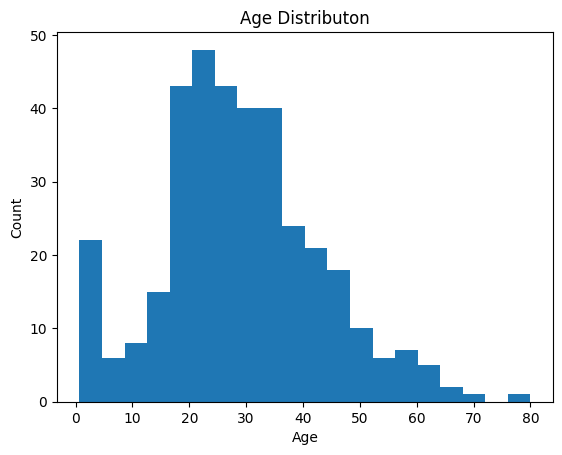

In [474]:
train["age"].plot(kind="hist", bins= 20)
plt.title("Age Distributon")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

kind...グラフの種類  
bins...20本に分布する

年齢の分布は若い方によっていて、20代や30代が多い。また0~5歳くらいの小さい子どもも少し多く20人以上いる。高齢者(50代以降)はかなり少ない。中央値で補完するのはいい気がするが中央が増えすぎてしまうため、一回中央値で補完したのち方法を考える

In [475]:
train.groupby("pclass")["age"].median()

pclass
1    36.0
2    29.0
3    25.0
Name: age, dtype: float64

客室クラスが高い方が、年齢が高い傾向にある。客室クラスごとの中央値を補完してみるといいかも

In [476]:
train.groupby("sex")["age"].median()

sex
female    26.0
male      29.0
Name: age, dtype: float64

In [593]:
train.groupby(["pclass", "sex"])["age"].median()

pclass  sex   
1       female    34.0
        male      37.0
2       female    27.5
        male      30.0
3       female    22.0
        male      26.0
Name: age, dtype: float64

##### ④運賃fare(重要)

In [478]:
train.groupby("survived")["fare"].mean()

survived
0    22.924262
1    50.359405
Name: fare, dtype: float64

生存者の方が運賃が高い傾向にはあるが最大値が512だったり第三四分位数が30ぐらいなので外れ値の影響も考えられるそのため平均だけでは断定できないので分布をみる

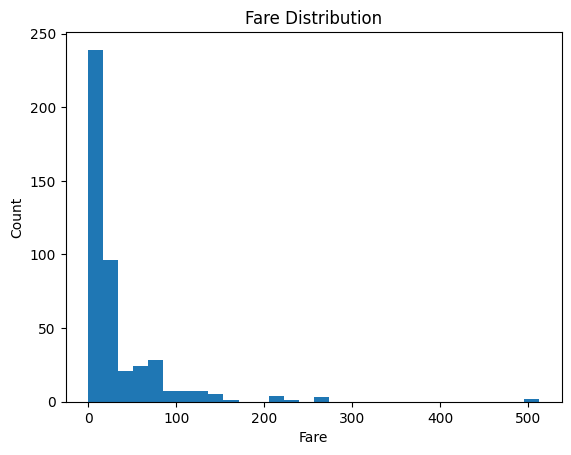

In [479]:
train["fare"].plot(kind="hist", bins=30)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

最大値である512は外れ値で0~100にほとんどの人がいる。かなり偏りがあることがわかる。運賃と生存率の関係をさらに分析する

In [480]:
train.groupby("survived")["fare"].describe()

,count,mean,std,min,25%,50%,75%,max
survived,,,,,,,,
0,266.0,22.924262,30.913610,0.000,7.8542,10.5,26.0000,263.0000
1,179.0,50.359405,69.930383,6.975,12.7375,26.0,61.4896,512.3292


In [481]:
train["fare_100"] = np.where(train["fare"] >= 100,"High", "Low")
train.groupby("fare_100")["survived"].mean()

fare_100
High    0.733333
Low     0.378313
Name: survived, dtype: float64

運賃が100超えてる人高い人の方がかなり生存率が高いことが分かった

In [482]:
train.groupby("fare_100")["pclass"].describe()

,count,mean,std,min,25%,50%,75%,max
fare_100,,,,,,,,
High,30.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
Low,415.0,2.390361,0.784453,1.0,2.0,3.0,3.0,3.0


運賃が100以上の人は全員1等客室、運賃と客室には相関関係がある

##### ⑤乗船した港embarked

In [483]:
train.groupby("embarked")["survived"].mean()

embarked
C    0.594937
Q    0.410256
S    0.350769
Name: survived, dtype: float64

Cから乗船した人生存率高い。Embarkedは生存率に影響している可能性があるが、Pclassなど他の特徴量との関係も考慮して分析する必要がある

In [484]:
train.groupby("embarked")["pclass"].describe()

,count,mean,std,min,25%,50%,75%,max
embarked,,,,,,,,
C,79.0,1.924051,0.944242,1.0,1.0,2.0,3.0,3.0
Q,39.0,2.974359,0.160128,2.0,3.0,3.0,3.0,3.0
S,325.0,2.313846,0.797348,1.0,2.0,3.0,3.0,3.0


Cはばらつきがかなりあり1~3の人が均等にいる  
Qは2以上の人しかいなく安価な階級な人が多い  
Sもばらつきは多少あるが安価な階級の人の方が多い

In [485]:
train["pclass_1"] = np.where(train["pclass"] <= 1,"1","2,3")
train["pclass_3"] = np.where(train["pclass"] >= 3,"3","1,2")

In [486]:
train.groupby(["embarked", "pclass_1"])["survived"].mean()

embarked  pclass_1
C         1           0.710526
          2,3         0.487805
Q         2,3         0.410256
S         1           0.661765
          2,3         0.268482
Name: survived, dtype: float64

In [487]:
train.groupby(["embarked", "pclass_3"])["survived"].mean()

embarked  pclass_3
C         1,2         0.702128
          3           0.437500
Q         1,2         1.000000
          3           0.394737
S         1,2         0.522581
          3           0.194118
Name: survived, dtype: float64

高級な客室であることが生存率に大きく影響している

### 6. 前処理

機械学習で扱える形式にするため、欠損値処理と文字データの変換を行う

### 6.1 基本前処理

In [488]:
test = train.copy()

trainのコピーをdfに

In [489]:
test.isnull().sum()

id           0
survived     0
pclass       0
sex          0
age         85
sibsp        0
parch        0
fare         0
embarked     2
fare_100     0
pclass_1     0
pclass_3     0
dtype: int64

#### Age補完

In [490]:
test["age"] = test["age"].fillna(test["age"].median())
test.isnull().sum()

id          0
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    2
fare_100    0
pclass_1    0
pclass_3    0
dtype: int64

median()...中央値  

中央値で補完した  
平均だと外れ値の影響を受けやすいと判断したため中央値を使用した

#### Embarked補完

In [491]:
test["embarked"] = test["embarked"].fillna(test["embarked"].mode()[0])
test.isnull().sum()

id          0
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
fare_100    0
pclass_1    0
pclass_3    0
dtype: int64

mode()...最頻値  
mode()はリストのような形で返すので[0]で最初の値を取り出す

カテゴリデータ(平均や中央値がない)であるため最頻値で補完した

#### sex数値化

In [492]:
test["sex"].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [493]:
test["sex"] = test["sex"].map({
  "female": 0,
  "male": 1
})
test.head()

,id,survived,pclass,sex,age,sibsp,parch,fare,embarked,fare_100,pclass_1,pclass_3
0,3,1,1,0,35.0,1,0,53.1000,S,Low,1,"1,2"
1,4,0,3,1,35.0,0,0,8.0500,S,Low,"2,3",3
2,7,0,3,1,2.0,3,1,21.0750,S,Low,"2,3",3
3,9,1,2,0,14.0,1,0,30.0708,C,Low,"2,3","1,2"
4,11,1,1,0,58.0,0,0,26.5500,S,Low,1,"1,2"


femaleを0、maleを1へ変換した  
機械学習モデルは文字列は扱えないため、数値へ変換する

In [494]:
test["embarked"].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [495]:
test["embarked"] = test["embarked"].map({
  "S": 0,
  "C": 1,
  "Q": 2
})
test.head()

,id,survived,pclass,sex,age,sibsp,parch,fare,embarked,fare_100,pclass_1,pclass_3
0,3,1,1,0,35.0,1,0,53.1000,0,Low,1,"1,2"
1,4,0,3,1,35.0,0,0,8.0500,0,Low,"2,3",3
2,7,0,3,1,2.0,3,1,21.0750,0,Low,"2,3",3
3,9,1,2,0,14.0,1,0,30.0708,1,Low,"2,3","1,2"
4,11,1,1,0,58.0,0,0,26.5500,0,Low,1,"1,2"


Sを0、Cを1、Qを2へ変換した

### 6.2 Age補完改善(pclassごと)

In [496]:
test_age = train.copy()

In [497]:
test_age.isnull().sum()

id           0
survived     0
pclass       0
sex          0
age         85
sibsp        0
parch        0
fare         0
embarked     2
fare_100     0
pclass_1     0
pclass_3     0
dtype: int64

In [498]:
test_age["age"] = (
  test_age.groupby("pclass")["age"].transform(lambda x: x.fillna(x.median()))
)
test_age.isnull().sum()

id          0
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    2
fare_100    0
pclass_1    0
pclass_3    0
dtype: int64

pclassごとに分けたグループそれぞれの中央値を計算してそれを補完する。xに分けたグループが順に入っている。groupbyで3行になったものをtransformで元のデータフレームに戻す。

In [499]:
test_age["embarked"] = test_age["embarked"].fillna(test_age["embarked"].mode()[0])
test_age.isnull().sum()

id          0
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
fare_100    0
pclass_1    0
pclass_3    0
dtype: int64

In [500]:
test_age["sex"] = test_age["sex"].map({
  "female": 0,
  "male": 1
})
test_age.head()

,id,survived,pclass,sex,age,sibsp,parch,fare,embarked,fare_100,pclass_1,pclass_3
0,3,1,1,0,35.0,1,0,53.1000,S,Low,1,"1,2"
1,4,0,3,1,35.0,0,0,8.0500,S,Low,"2,3",3
2,7,0,3,1,2.0,3,1,21.0750,S,Low,"2,3",3
3,9,1,2,0,14.0,1,0,30.0708,C,Low,"2,3","1,2"
4,11,1,1,0,58.0,0,0,26.5500,S,Low,1,"1,2"


In [501]:
test_age["embarked"] = test_age["embarked"].map({
  "S": 0,
  "C": 1,
  "Q": 2
})
test_age.head()

,id,survived,pclass,sex,age,sibsp,parch,fare,embarked,fare_100,pclass_1,pclass_3
0,3,1,1,0,35.0,1,0,53.1000,0,Low,1,"1,2"
1,4,0,3,1,35.0,0,0,8.0500,0,Low,"2,3",3
2,7,0,3,1,2.0,3,1,21.0750,0,Low,"2,3",3
3,9,1,2,0,14.0,1,0,30.0708,1,Low,"2,3","1,2"
4,11,1,1,0,58.0,0,0,26.5500,0,Low,1,"1,2"


### 6.3 Age補完改善(pclass&sexごと)

In [594]:
test_age2 = train.copy()

In [595]:
test_age2.isnull().sum()

id           0
survived     0
pclass       0
sex          0
age         85
sibsp        0
parch        0
fare         0
embarked     2
fare_100     0
pclass_1     0
pclass_3     0
dtype: int64

In [596]:
test_age2["age"] = (
  test_age2.groupby(["pclass", "sex"])["age"].transform(lambda x: x.fillna(x.median()))
)
test_age2.isnull().sum()

id          0
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    2
fare_100    0
pclass_1    0
pclass_3    0
dtype: int64

In [597]:
test_age2["embarked"] = test_age2["embarked"].fillna(test_age2["embarked"].mode()[0])
test_age2.isnull().sum()

id          0
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
fare_100    0
pclass_1    0
pclass_3    0
dtype: int64

In [598]:
test_age2["sex"] = test_age2["sex"].map({
  "female": 0,
  "male": 1
})
test_age2.head()

,id,survived,pclass,sex,age,sibsp,parch,fare,embarked,fare_100,pclass_1,pclass_3
0,3,1,1,0,35.0,1,0,53.1000,S,Low,1,"1,2"
1,4,0,3,1,35.0,0,0,8.0500,S,Low,"2,3",3
2,7,0,3,1,2.0,3,1,21.0750,S,Low,"2,3",3
3,9,1,2,0,14.0,1,0,30.0708,C,Low,"2,3","1,2"
4,11,1,1,0,58.0,0,0,26.5500,S,Low,1,"1,2"


In [599]:
test_age2["embarked"] = test_age2["embarked"].map({
  "S": 0,
  "C": 1,
  "Q": 2
})
test_age2.head()

,id,survived,pclass,sex,age,sibsp,parch,fare,embarked,fare_100,pclass_1,pclass_3
0,3,1,1,0,35.0,1,0,53.1000,0,Low,1,"1,2"
1,4,0,3,1,35.0,0,0,8.0500,0,Low,"2,3",3
2,7,0,3,1,2.0,3,1,21.0750,0,Low,"2,3",3
3,9,1,2,0,14.0,1,0,30.0708,1,Low,"2,3","1,2"
4,11,1,1,0,58.0,0,0,26.5500,0,Low,1,"1,2"


### 7. 特徴量作成

説明変数と目的変数を分ける

In [502]:
X = test.drop(columns=["id", "survived", "fare_100", "pclass_1", "pclass_3"])
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,1,0,35.0,1,0,53.1000,0
1,3,1,35.0,0,0,8.0500,0
2,3,1,2.0,3,1,21.0750,0
3,2,0,14.0,1,0,30.0708,1
4,1,0,58.0,0,0,26.5500,0


Xは機械学習モデルに入力する特徴量  
[]の列を取り除いたデータにする

In [503]:
Y = test["survived"]

Yは機械学習モデルが予測したい正解データ

### 7.1 FamilySize  
sibsとparchを組み合わせ、家族人数を表す特徴量を作成する。複数人で乗っていた方が生存率高そう。

In [504]:
test["FamilySize"] = test["sibsp"] + test["parch"] + 1
test.head()
X1 = test.drop(columns=["id", "survived", "fare_100", "pclass_1", "pclass_3"])
X1.head()

,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize
0,1,0,35.0,1,0,53.1000,0,2
1,3,1,35.0,0,0,8.0500,0,1
2,3,1,2.0,3,1,21.0750,0,5
3,2,0,14.0,1,0,30.0708,1,2
4,1,0,58.0,0,0,26.5500,0,1


### 7.2 FamilySize(置き換え)  

In [505]:
X2 = test.drop (columns=["id", "survived", "fare_100", "pclass_1", "pclass_3", "sibsp", "parch"])
X2.head()

,pclass,sex,age,fare,embarked,FamilySize
0,1,0,35.0,53.1000,0,2
1,3,1,35.0,8.0500,0,1
2,3,1,2.0,21.0750,0,5
3,2,0,14.0,30.0708,1,2
4,1,0,58.0,26.5500,0,1


### 7.3 IsAlone  
家族と一緒に乗船したか、一人で乗船したかを表す特徴量を作成する。具体的な人数ではなく家族とか1人でかで違いが出るかを見る。

In [506]:
test["IsAlone"] = (test["FamilySize"] == 1).astype(int)
test[["FamilySize", "IsAlone"]].head()
X3 = test.drop(columns=["id", "survived", "fare_100", "pclass_1", "pclass_3"])
X3.head()

,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize,IsAlone
0,1,0,35.0,1,0,53.1000,0,2,0
1,3,1,35.0,0,0,8.0500,0,1,1
2,3,1,2.0,3,1,21.0750,0,5,0
3,2,0,14.0,1,0,30.0708,1,2,0
4,1,0,58.0,0,0,26.5500,0,1,1


### 7.4 IsAlone(置き換え)

In [507]:
X4 = test.drop(columns=["id", "survived", "fare_100", "pclass_1", "pclass_3", "sibsp", "parch", "FamilySize"])
X4.head()

,pclass,sex,age,fare,embarked,IsAlone
0,1,0,35.0,53.1000,0,0
1,3,1,35.0,8.0500,0,1
2,3,1,2.0,21.0750,0,0
3,2,0,14.0,30.0708,1,0
4,1,0,58.0,26.5500,0,1


### 7.5 Pclass別Age補完

In [508]:
X5 = test_age.drop(columns=["id", "survived", "fare_100", "pclass_1", "pclass_3"])
X5.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,1,0,35.0,1,0,53.1000,0
1,3,1,35.0,0,0,8.0500,0
2,3,1,2.0,3,1,21.0750,0
3,2,0,14.0,1,0,30.0708,1
4,1,0,58.0,0,0,26.5500,0


In [509]:
Y5 = test_age["survived"]

### 7.6 Pclass&sex別Age補完

In [600]:
X6 = test_age2.drop(columns=["id", "survived", "fare_100", "pclass_1", "pclass_3"])
X6.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,1,0,35.0,1,0,53.1000,0
1,3,1,35.0,0,0,8.0500,0
2,3,1,2.0,3,1,21.0750,0
3,2,0,14.0,1,0,30.0708,1
4,1,0,58.0,0,0,26.5500,0


In [601]:
Y6 = test_age2["survived"]

### 8. モデル作成

### 8.1 Decision Tree  
#### 採用理由
最初のベースラインモデルとして採用

#### 学習データとテストデータへの分割  
データを学習用と評価用に分割し、未知のデータに対する性能を確認できるようにした

In [510]:
from sklearn.model_selection import train_test_split

scikit-learnのライブラリの中にあるmodel_selectionからデータを学習用とテスト用に分けるための関数をインポート

In [511]:
X_train, X_test, Y_train, Y_test =train_test_split(
  X,
  Y,
  test_size=0.2,
  random_state=42
)

データを学習用8割、テスト(評価)用2割にランダムに切り分ける  
test_size...テスト用の割合を指定  
random_state...データのシャッフルの仕方を固定する。毎回同じ分割結果になるようにした

In [512]:
X_train.head()

,pclass,sex,age,sibsp,parch,fare,embarked
24,3,1,28.5,0,0,7.2292,1
17,2,0,27.0,1,0,21.0000,0
66,1,0,19.0,0,2,26.2833,0
176,1,1,25.0,1,0,55.4417,1
247,3,1,28.0,0,0,24.1500,2


#### 学習

In [513]:
from sklearn.tree import DecisionTreeClassifier

sklearn...pythonで機械学習をするためのライブラリ  
DecisionTreeClassifier...分類問題のための決定木モデル

In [514]:
import sklearn
sklearn.set_config(display="text")

scikit-learnの設定（config）を変更して、画面への表示（display）を綺麗な図（diagram）ではなく、シンプルな文字（text）にするようにした

In [515]:
model = DecisionTreeClassifier(random_state=42)

モデルを作る  
AIを準備した

In [516]:
model.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

fit()...特徴量(X_train)と正解データ(y_train)の関係を学習し、生存予測モデルを作成した

#### 予測

In [517]:
Y_pred = model.predict(X_test)

predict()...予測する  
テスト用のX_testから予測したものがY_predに

In [518]:
Y_pred[:10]

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 0])

Y_predの上から10個表示  
1生存、0死亡

#### モデルの評価

In [519]:
from sklearn.metrics import accuracy_score

sklearn.metrics...モデルを評価するための機能  
accuracy_score...正解率(Accuracy)を計算

In [520]:
accuracy = accuracy_score(Y_test,Y_pred)
accuracy

0.7752808988764045

 Accuracyは約78%であった。
最初のモデルとしては十分だが、モデルのパラメータや特徴量を工夫することでさらに精度を向上させたい

In [521]:
importance = model.feature_importances_

for feature, score in zip(X.columns, importance):
  print(feature,score)

pclass 0.0714591982175421
sex 0.31055167971841613
age 0.2436480460634685
sibsp 0.10243637620833274
parch 0.012033725336174896
fare 0.2332977325989169
embarked 0.026573241857148665


feature_importances_...特徴量が予測にどれくらい役立ったかを表す値  
zip(X.columns, importance)で列の名前と重要度を結び付ける(ペアを作る)  
それをfeature,scoreとして表示

#### 特徴量重要度
-sexが最も重要な特徴量となった  
-ageとfareも重要度が高かった  
-EDAではpclassが重要と考えたが、fareとの相関が強いため重要度が低くなった可能性がある

### 8.2 RandomForest 
#### 採用理由  
Decision Treeは一本の木だけで予測するため、データによっては過学習しやすいという特徴がある。そこで複数の決定木を組み合わせるRandomForestを用いて精度向上を目指す

#### 学習

In [522]:
from sklearn.ensemble import RandomForestClassifier

RandomForestClassifier...決定木を何本も作り多数決で予測するモデル

In [523]:
rf_model = RandomForestClassifier(
  n_estimators = 100,
  random_state=42
)

n_estimators...木の本数  
モデル作成

In [524]:
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

学習し、生存予測モデルを作成した

#### 予測

In [525]:
rf_pred = rf_model.predict(X_test)
rf_pred[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0])

#### モデルの評価

In [526]:
rf_accurasy = accuracy_score(Y_test,rf_pred)
rf_accurasy

0.8426966292134831

Accuracyは約84%まで増加した。今後も改善を進める。

In [527]:
importance = rf_model.feature_importances_
for feature, rf_score in zip(X.columns, importance):
  print(feature, rf_score)

pclass 0.08476829568094985
sex 0.24246272864284824
age 0.26563056954801334
sibsp 0.06729988422681037
parch 0.045722475071737725
fare 0.25295960475588053
embarked 0.04115644207375979


#### 特徴量重要度  
-ageとfareとsexの重要度が同じくらい高い

### 8.3 RandomForest + FamilySize  
#### 採用理由  
FamilySizeを追加することで、精度向上するか検証する

#### 学習データとテストデータへの分割

In [528]:
X1_train, X1_test, Y1_train, Y1_test =train_test_split(
  X1,
  Y,
  test_size=0.2,
  random_state=42
)

#### 学習

In [529]:
rf_model1 = RandomForestClassifier(
  n_estimators = 100,
  random_state=42
)

In [530]:
rf_model1.fit(X1_train, Y1_train)

RandomForestClassifier(random_state=42)

#### 予測

In [531]:
rf_pred1 = rf_model1.predict(X1_test)
rf_pred1[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 1])

#### モデルの評価

In [532]:
rf_accurasy1 = accuracy_score(Y1_test, rf_pred1)
rf_accurasy1

0.797752808988764

### 8.4 RandomForest + FamilySize(置き換え)  
#### 採用理由  
FamilySizeを追加しているのでsibspやparchを削除することで、精度向上するか検証する

#### 学習データとテストデータへの分割

In [533]:
X2_train, X2_test, Y2_train, Y2_test =train_test_split(
  X2,
  Y,
  test_size=0.2,
  random_state=42
)

#### 学習

In [534]:
rf_model2 = RandomForestClassifier(
  n_estimators = 100,
  random_state=42
)

In [535]:
rf_model2.fit(X2_train, Y2_train)

RandomForestClassifier(random_state=42)

#### 予測

In [536]:
rf_pred2 = rf_model2.predict(X2_test)
rf_pred2[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0])

#### モデルの評価

In [537]:
rf_accurasy2 = accuracy_score(Y2_test, rf_pred2)
rf_accurasy2

0.797752808988764

### 8.5 RandomForest + IsAlone
#### 採用理由  
IsAloneを追加することで、一人で乗船したかの情報が予測精度向上に役立つか検証する

#### 学習データとテストデータへの分割  

In [538]:
X3_train, X3_test, Y3_train, Y3_test =train_test_split(
  X3,
  Y,
  test_size=0.2,
  random_state=42
)
X3_train.head()

,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize,IsAlone
24,3,1,28.5,0,0,7.2292,1,1,1
17,2,0,27.0,1,0,21.0000,0,2,0
66,1,0,19.0,0,2,26.2833,0,3,0
176,1,1,25.0,1,0,55.4417,1,2,0
247,3,1,28.0,0,0,24.1500,2,1,1


#### 学習

In [539]:
rf_model3 = RandomForestClassifier(
  n_estimators=100,
  random_state=42
)

In [540]:
rf_model3.fit(X3_train, Y3_train)

RandomForestClassifier(random_state=42)

#### 予測

In [541]:
rf_pred3 = rf_model3.predict(X3_test)
rf_pred3[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0])

#### モデルの評価

In [542]:
rf_accurasy3 = accuracy_score(Y3_test, rf_pred3)
rf_accurasy3

0.8089887640449438

In [543]:
importance3 = rf_model3.feature_importances_
for feature, rf_score3 in zip(X3.columns, importance3):
  print(feature, rf_score3)

pclass 0.08337447245955155
sex 0.25477039671374174
age 0.256575247320344
sibsp 0.03862879307408593
parch 0.02400196648170849
fare 0.22887375333233925
embarked 0.04186867774082673
FamilySize 0.05286476441729157
IsAlone 0.019041928460110814


### 8.6 RandomForest + IsAlone(置き換え)
#### 採用理由  
IsAloneを追加して精度向上したため、ほかの部分を削除して情報量を整理し、精度向上するかを検証する

#### 学習データとテストデータへの分割  

In [544]:
X4_train, X4_test, Y4_train, Y4_test =train_test_split(
  X4,
  Y,
  test_size=0.2,
  random_state=42
)

#### 学習

In [545]:
rf_model4 = RandomForestClassifier(
  n_estimators=100,
  random_state=42
)

In [546]:
rf_model4.fit(X4_train, Y4_train)

RandomForestClassifier(random_state=42)

#### 予測

In [547]:
rf_pred4 = rf_model4.predict(X4_test)
rf_pred4[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 1])

#### モデルの評価

In [548]:
rf_accurasy4 = accuracy_score(Y4_test, rf_pred4)
rf_accurasy4

0.7865168539325843

In [549]:
importance4 = rf_model4.feature_importances_
for feature, rf_score4 in zip(X4.columns, importance4):
  print(feature, rf_score4)

pclass 0.08950645288435435
sex 0.2471921013815618
age 0.27952961331167875
fare 0.29149916685686245
embarked 0.045643148302407247
IsAlone 0.04662951726313537


### 8.7 RandomForest + Pclass別Age補完  
#### 採用理由  
全体の中央値ではなく、pclassごとの中央値で補完する方法を検証する

#### 学習データとテストデータへの分割

In [550]:
X5_train, X5_test, Y5_train, Y5_test =train_test_split(
  X5,
  Y5,
  test_size=0.2,
  random_state=42
)

#### 学習

In [551]:
rf_model5 = RandomForestClassifier(
  n_estimators= 100,
  random_state=42
)

In [552]:
rf_model5.fit(X5_train, Y5_train)

RandomForestClassifier(random_state=42)

#### 予測

In [553]:
rf_pred5 = rf_model5.predict(X5_test)
rf_pred5[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0])

#### モデルの評価

In [554]:
rf_accurasy5 = accuracy_score(Y5_test, rf_pred5)
rf_accurasy5

0.8202247191011236

### 8.8 RandomForest(max_depthを調整) + Pclass別Age補完  
#### 採用理由  
木の深さを制限することで過学習を抑え、精度向上を目指す

#### 学習

In [589]:
rf_model6 = RandomForestClassifier(
  n_estimators=100,
  random_state=42,
  max_depth=5
)

In [590]:
rf_model6.fit(X5_train, Y5_train)

RandomForestClassifier(max_depth=5, random_state=42)

#### 予測

In [591]:
rf_pred6 = rf_model6.predict(X5_test)
rf_pred6[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0])

#### モデルの評価

In [592]:
rf_accurasy6 = accuracy_score(Y5_test,rf_pred6)
rf_accurasy6

0.8426966292134831

### 8.9 RandomForest(max_depthを調整) + Pclass&sex別Age補完  
#### 採用理由  
Pclass&sexごとでもかなり中央値に違いがあったのでこっちもみてみる

#### 学習データとテストデータへの分割

In [602]:
X6_train, X6_test, Y6_train, Y6_test =train_test_split(
  X6,
  Y6,
  test_size=0.2,
  random_state=42
)

#### 学習

In [616]:
rf_model7 = RandomForestClassifier(
  n_estimators=100,
  random_state=42,
  max_depth=5
)

In [617]:
rf_model7.fit(X6_train, Y6_train)

RandomForestClassifier(max_depth=5, random_state=42)

#### 予測

In [618]:
rf_pred7 = rf_model7.predict(X6_test)
rf_pred7[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0])

#### モデルの評価

In [619]:
rf_accurasy7 = accuracy_score(Y6_test,rf_pred7)
rf_accurasy7

0.8426966292134831

### 9. 提出

#### データ読み込み&EDA

In [555]:
train_test = pd.read_csv("../data/test.csv")
train_test.head()

,id,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,2,3,female,26.0,0,0,7.9250,S
3,5,3,male,NaN,0,0,8.4583,Q
4,6,1,male,54.0,0,0,51.8625,S


In [556]:
train_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        446 non-null    int64  
 1   pclass    446 non-null    int64  
 2   sex       446 non-null    str    
 3   age       354 non-null    float64
 4   sibsp     446 non-null    int64  
 5   parch     446 non-null    int64  
 6   fare      446 non-null    float64
 7   embarked  446 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 28.0 KB


In [557]:
train_test.isnull().sum()

id           0
pclass       0
sex          0
age         92
sibsp        0
parch        0
fare         0
embarked     0
dtype: int64

#### 前処理

In [558]:
test_df = train_test.copy()

In [559]:
test_df["age"] = test_df["age"].fillna(test["age"].median())
test_df.isnull().sum()

id          0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

In [560]:
test_df ["sex"] = test_df["sex"].map({
  "female": 0,
  "male": 1
})
test_df.head()

,id,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,2,3,0,26.0,0,0,7.9250,S
3,5,3,1,28.0,0,0,8.4583,Q
4,6,1,1,54.0,0,0,51.8625,S


In [561]:
test_df["embarked"] = test_df["embarked"].map({
  "S": 0,
  "C": 1,
  "Q": 2
})
test_df.head()

,id,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,0
1,1,1,0,38.0,1,0,71.2833,1
2,2,3,0,26.0,0,0,7.9250,0
3,5,3,1,28.0,0,0,8.4583,2
4,6,1,1,54.0,0,0,51.8625,0


In [562]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        446 non-null    int64  
 1   pclass    446 non-null    int64  
 2   sex       446 non-null    int64  
 3   age       446 non-null    float64
 4   sibsp     446 non-null    int64  
 5   parch     446 non-null    int64  
 6   fare      446 non-null    float64
 7   embarked  446 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 28.0 KB


### 9.1 Decision Tree

#### 予測

In [563]:
X_submit = test_df.drop(columns=["id"])
prediction = model.predict(X_submit)
prediction[:10]

array([0, 1, 0, 0, 0, 1, 1, 0, 1, 1])

#### 提出用CSV作成

In [564]:
submission = pd.DataFrame({
  "id": train_test["id"],
  "survived": prediction
})
submission.head()

,id,survived
0,0,0
1,1,1
2,2,0
3,5,0
4,6,0


In [565]:
submission.to_csv("submission.csv", index=False, header=False)

### 9.2 RandomForest

#### 予測

In [566]:
prediction = rf_model.predict(X_submit)
prediction[:10]

array([0, 1, 1, 0, 0, 1, 1, 0, 1, 0])

#### 提出用CSV作成

In [567]:
submission = pd.DataFrame({
  0: train_test["id"],
  1: prediction
})
submission.to_csv("submission.csv", index=False, header=False)

### 9.3 RandomForest(max_depthを調整) + Pclass別Age補完

### 10. 結果

| No. | モデル | 変更内容 | Accuracy | SIGNATE Score | 結果 |
|:---:|:-------|:---------|---------:|---------------:|:-----|
| 1 | Decision Tree | ベースラインモデル | 0.7753 | 0.7469 | 初提出 |
| 2 | Random Forest | モデルをRandomForestへ変更 | 0.8427 | 0.7912 | 精度向上 |

### 11. 改善点

-RandomForestへ変更✓  
-特徴量を追加  
-Ageの補完方法を改善  
-ハイパラメータ調整

### 12. 学んだこと